In [ ]:
# Libraries

import os # Provides functions for interacting with the operating system, like file paths and directories.
import shutil # Offers high-level file operations, such as copying and moving files.
import numpy as np # Fundamental package for scientific computing with Python, especially for arrays.
import matplotlib.pyplot as plt # A plotting library for creating static, interactive, and animated visualizations.

import tensorflow as tf # Google's open-source machine learning framework.

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Utility for real-time data augmentation on image data.
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D # Input: Defines the input shape; Conv2D: 2D Convolutional Layer for feature extraction; MaxPooling2D: Reduces spatial dimensions; UpSampling2D: Increases spatial dimensions.
from tensorflow.keras.models import Model # Used to define a Keras model.

In [ ]:
#import dataset

import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [ ]:
#Create a smaller dataset (5000 images)
source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("Copied",len(images),"images")

Copied 5000 images


In [ ]:
#configure kaggle
# Create a .kaggle directory in the user's home directory if it doesn't exist
!mkdir -p ~/.kaggle
# Copy the kaggle.json file (which contains API credentials) to the .kaggle directory
!cp kaggle.json ~/.kaggle/
# Set appropriate permissions for the kaggle.json file (read/write for owner only) for security
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Data Preprocessing
# Define the target image dimensions (width, height) for resizing all input images.
IMAGE_SIZE =(64,64)
# Define the number of samples (images) to be processed in one batch during training/inference.
BATCH_SIZE =32

In [ ]:
from IPython.utils.text import re # Imports the 're' module for regular expressions from IPython's utility library.
datagen=ImageDataGenerator(
    rescale=1./255, # Rescales pixel values from [0, 255] to [0, 1] for normalization.
    validation_split=0.2 # Reserves 20% of the images for validation.
)

In [ ]:
# Load Dataset
train_generator=datagen.flow_from_directory(
    "celeba_small", # Specifies the directory containing the images for the generator.
    target_size=IMAGE_SIZE, # Resizes all images to the dimensions defined by IMAGE_SIZE (64x64).
    batch_size=BATCH_SIZE, # Sets the number of images to yield in each batch (32 images).
    class_mode="input", # For autoencoders, the input is also the target, so 'input' is used.
    subset="training" # Specifies that this generator should use the training subset of the data.
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small", # Specifies the directory for validation images.
    target_size=IMAGE_SIZE, # Resizes images to the defined IMAGE_SIZE.
    batch_size=BATCH_SIZE, # Sets the number of images per batch.
    class_mode="input", # Input is also the target for autoencoders.
    subset="validation" # Uses the validation subset of the data.
)

Found 1000 images belonging to 1 classes.


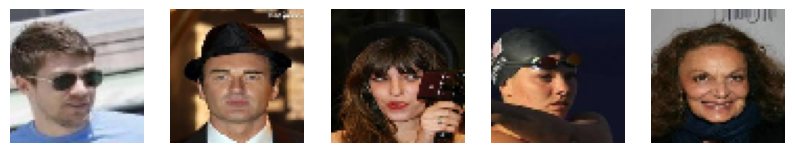

In [ ]:
#Diaplay Sample Images
images,_ = next(train_generator) # Get a batch of images from the training generator.
plt.figure(figsize=(10,5)) # Create a new figure with a specified size.
for i in range(5): # Loop through the first 5 images in the batch.
    plt.subplot(1,5,i+1) # Create a subplot for each image (1 row, 5 columns).
    plt.imshow(images[i]) # Display the current image.
    plt.axis('off') # Turn off the axis for a cleaner look.
plt.show() # Show the plot with all displayed images.

In [ ]:
#Build Convolutional Autoencoder
#Encoder

input_img = Input(shape=(64,64,3)) # Define the input image shape (height, width, channels).
x=Conv2D(
    32, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same' # Keep output size same as input
)(input_img)
x= MaxPooling2D(
    (2,2), # Pool size
    padding='same' # Keep output size same as input
)(x)
x=Conv2D(
    64, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(x)
encoded= MaxPooling2D(
    (2,2), # Pool size
    padding='same'
)(x)

In [ ]:
#Decoder
from IPython.utils.py3compat import decode
x=Conv2D(
    64, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(encoded)
x=UpSampling2D((2,2))(x) # Upsamples the spatial dimensions by a factor of 2.
x=Conv2D(
    32, # Number of filters
    (3,3), # Filter size
    activation='relu',
    padding='same'
)(x)
x=UpSampling2D((2,2))(x) # Upsamples the spatial dimensions by a factor of 2.
decoded=Conv2D(
    3, # Output channels (e.g., 3 for RGB image)
    (3,3), # Filter size
    activation='sigmoid', # Sigmoid for pixel values between 0 and 1
    padding='same'
)(x)


In [ ]:
#create model
autoencoder= Model(
    input_img, # Specifies the input layer of the model.
    decoded # Specifies the output layer of the model, which is the reconstructed image from the decoder.
)

In [21]:
#compile Model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), # Specifies the Adam optimizer with the defined LEARNING_RATE.
    loss='binary_crossentropy'
# Uses binary cross-entropy as the loss function, suitable for pixel-wise reconstruction with values between 0 and 1.
)

In [ ]:
#Model summary
autoencoder.summary()
# Displays a summary of the autoencoder model's architecture, including layer types, output shapes, and the number of parameters.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Train Model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=NUM_EPOCHS # Use the defined NUM_EPOCHS for training iterations.
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.4859 - val_loss: 0.4823
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4822 - val_loss: 0.4845
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4821 - val_loss: 0.4820
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4821 - val_loss: 0.4819
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4817 - val_loss: 0.4815
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4815 - val_loss: 0.4823
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4815 - val_loss: 0.4810
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4811 - val_loss: 0.4809
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.4809 - val_loss: 0.4812
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4805 - val_loss: 0.4805
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4808 - val_loss: 0.4808
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 

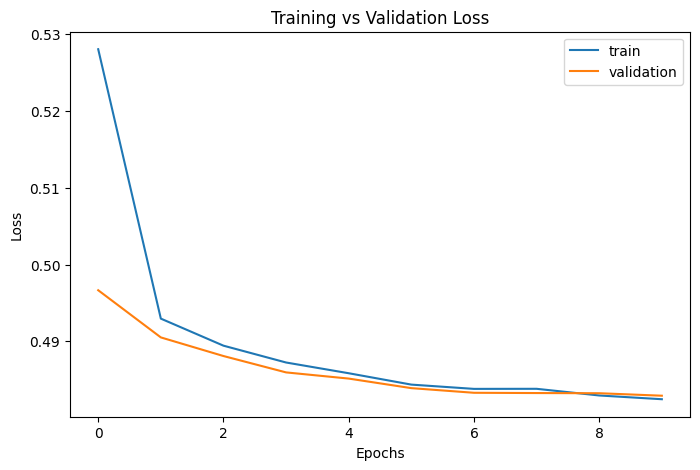

In [ ]:
#Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training vs Validation Loss")
plt.legend(['train','validation'])
plt.show()

In [ ]:
#Evaluate Model
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.4829
Validation Loss: 0.48292508721351624


In [ ]:
#Reconstruct Images
images,_=next(validation_generator)
reconstructed=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step


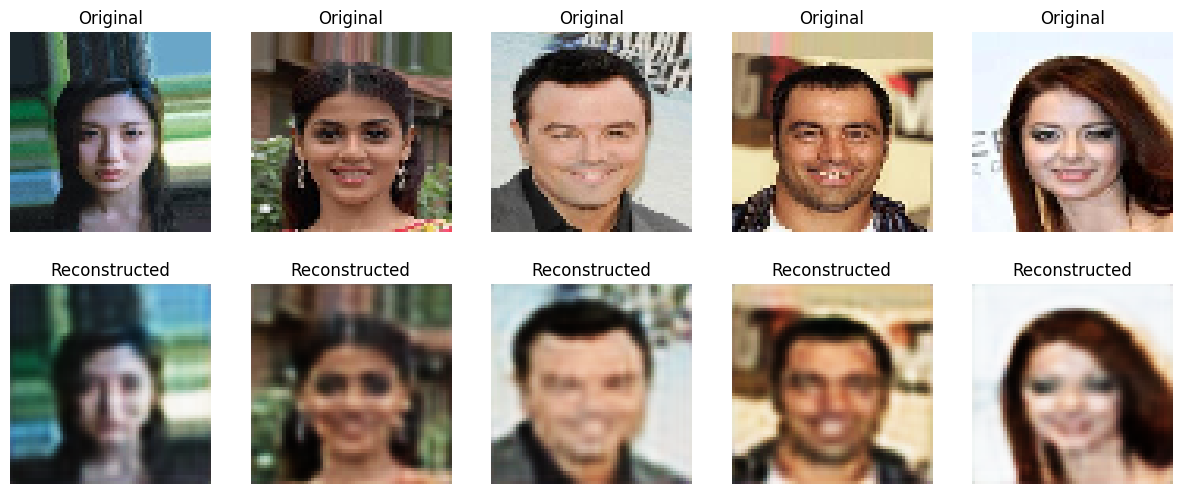

In [ ]:
#Display Results
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis('off')
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis('off')
plt.show()

## Automate Training and Result Saving

To streamline experimentation with different hyperparameters, we can create a function that handles the model building, training, and visualization of results. This function will also save the output plot for easy comparison.

In [25]:
def train_and_evaluate_autoencoder(learning_rate, num_epochs, experiment_name="experiment"):
    """
    Builds, compiles, trains, and evaluates the autoencoder model.

    Args:
        learning_rate (float): The learning rate for the Adam optimizer.
        num_epochs (int): The number of epochs for training.
        experiment_name (str): A unique name for this experiment to save results.
    """

    print(f"\n--- Starting Experiment: {experiment_name} ---")
    print(f"Learning Rate: {learning_rate}, Epochs: {num_epochs}")

    # 1. Build Autoencoder Model (Encoder part)
    input_img = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # 2. Build Autoencoder Model (Decoder part)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # 3. Create the Model
    autoencoder_fn = Model(input_img, decoded)

    # 4. Compile Model
    autoencoder_fn.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy'
    )
    autoencoder_fn.summary()

    # 5. Train Model
    print("\nTraining Model...")
    history = autoencoder_fn.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=num_epochs,
        verbose=1 # Show progress during training
    )
    print("Training Complete.")

    # 6. Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f"Training vs Validation Loss ({experiment_name})")
    plt.legend()
    loss_plot_filename = f'loss_plot_{experiment_name}.png'
    plt.savefig(loss_plot_filename)
    plt.show()
    print(f"Loss plot saved as '{loss_plot_filename}'")

    # 7. Evaluate Model
    loss = autoencoder_fn.evaluate(validation_generator, verbose=0)
    print(f"Validation Loss for {experiment_name}: {loss}")

    # 8. Reconstruct Images
    images_batch, _ = next(validation_generator)
    reconstructed_images = autoencoder_fn.predict(images_batch, verbose=0)

    # 9. Display and Save Results
    n = 5 # Number of images to display
    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images_batch[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i])
        plt.title("Reconstructed")
        plt.axis('off')
    plt.suptitle(f"Original vs Reconstructed Images ({experiment_name})")
    reconstruction_plot_filename = f'reconstruction_plot_{experiment_name}.png'
    plt.savefig(reconstruction_plot_filename)
    plt.show()
    print(f"Reconstruction plot saved as '{reconstruction_plot_filename}'")

    # Optionally save the model
    model_filename = f'autoencoder_{experiment_name}.keras'
    autoencoder_fn.save(model_filename)
    print(f"Model saved as '{model_filename}'")

    print(f"--- Experiment: {experiment_name} Finished ---")
    return autoencoder_fn, history


### Run an Automated Experiment

Now, let's use the function to run an experiment with our current hyperparameters and observe the output. You can easily change these values and run multiple experiments to compare results.


--- Starting Experiment: default_params ---
Learning Rate: 0.001, Epochs: 20


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)


Training Model...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.5270 - val_loss: 0.4958
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.4918 - val_loss: 0.4888
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4884 - val_loss: 0.4871
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4866 - val_loss: 0.4855
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.4852 - val_loss: 0.4866
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4844 - val_loss: 0.4879
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4845 - val_loss: 0.4835
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4833 - val_loss: 0.4830
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4831 - val_loss: 0.4831
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4831 - val_loss: 0.4834
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4828 - val_loss: 0.4834
Epoch 12/20
125/125 ━━

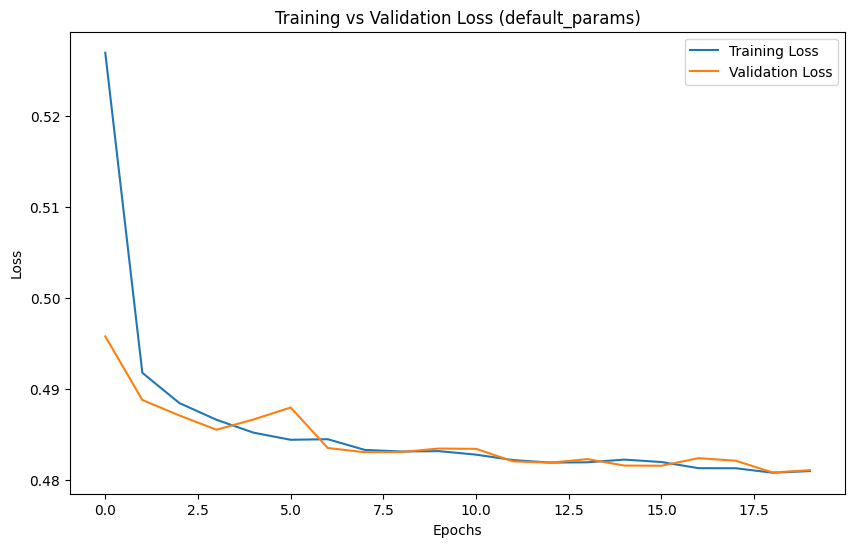

Loss plot saved as 'loss_plot_default_params.png'
Validation Loss for default_params: 0.48104575276374817


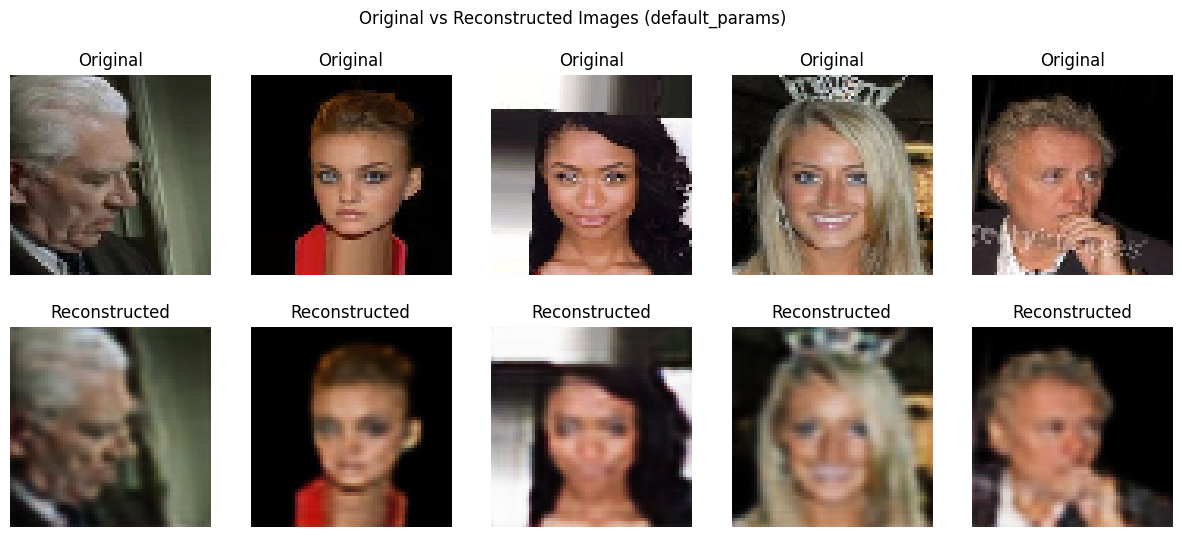

Reconstruction plot saved as 'reconstruction_plot_default_params.png'
Model saved as 'autoencoder_default_params.keras'
--- Experiment: default_params Finished ---


In [26]:
# Example of running the automated training and evaluation function
# We'll use the LEARNING_RATE and NUM_EPOCHS defined earlier.

# You can change these values to run different experiments:
# new_learning_rate = 0.0005
# new_num_epochs = 25

# Run the function
final_autoencoder, final_history = train_and_evaluate_autoencoder(
    learning_rate=LEARNING_RATE,
    num_epochs=NUM_EPOCHS,
    experiment_name='default_params'
)


### Run a Second Automated Experiment with Different Hyperparameters

Now, let's run a second experiment with a modified learning rate and increased epochs to observe its impact on the model's performance.


--- Starting Experiment: tuned_params_lr0.0005_e30 ---
Learning Rate: 0.0005, Epochs: 30


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)


Training Model...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.5415 - val_loss: 0.5012
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4967 - val_loss: 0.4942
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4917 - val_loss: 0.4901
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4895 - val_loss: 0.4886
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.4877 - val_loss: 0.4873
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4867 - val_loss: 0.4868
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4863 - val_loss: 0.4858
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.4853 - val_loss: 0.4850
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4847 - val_loss: 0.4852
Epoch 10/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4842 - val_loss: 0.4845
Epoch 11/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.4843 - val_loss: 0.4838
Epoch 12/30
125/125 ━━

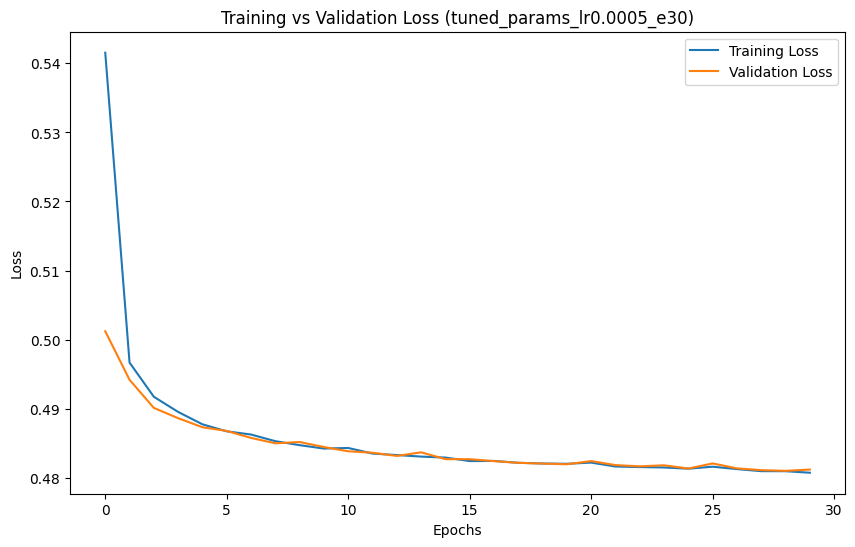

Loss plot saved as 'loss_plot_tuned_params_lr0.0005_e30.png'
Validation Loss for tuned_params_lr0.0005_e30: 0.48119816184043884


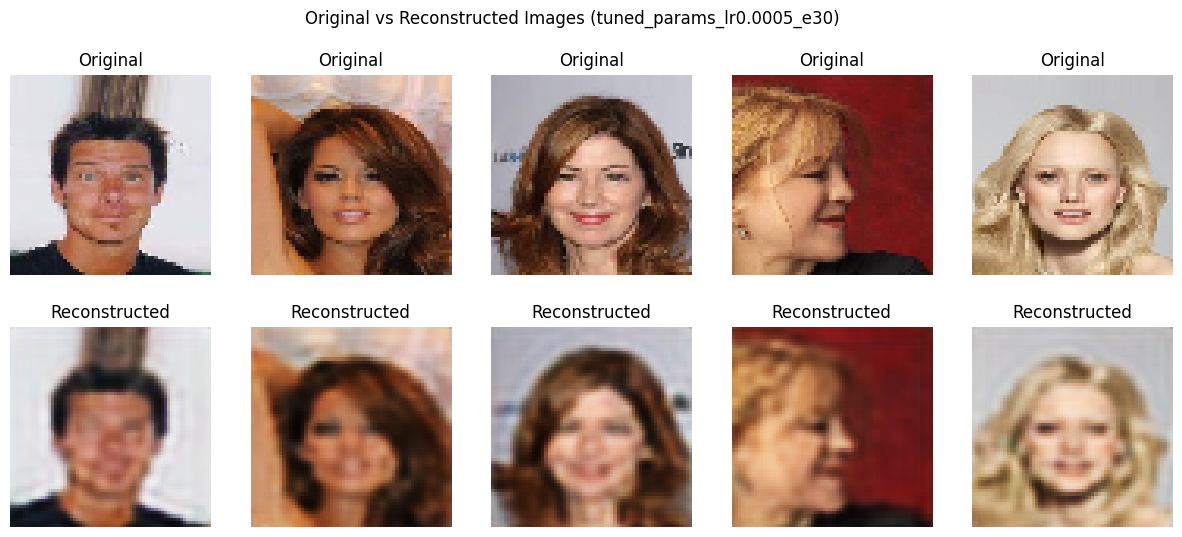

Reconstruction plot saved as 'reconstruction_plot_tuned_params_lr0.0005_e30.png'
Model saved as 'autoencoder_tuned_params_lr0.0005_e30.keras'
--- Experiment: tuned_params_lr0.0005_e30 Finished ---


In [27]:
# Define new hyperparameters for the second experiment
new_learning_rate = 0.0005
new_num_epochs = 30

# Run the function with the new parameters
second_autoencoder, second_history = train_and_evaluate_autoencoder(
    learning_rate=new_learning_rate,
    num_epochs=new_num_epochs,
    experiment_name='tuned_params_lr0.0005_e30'
)


### Compare Loss Plots of Different Experiments

Let's visualize the loss plots from both experiments to compare their training and validation performance.

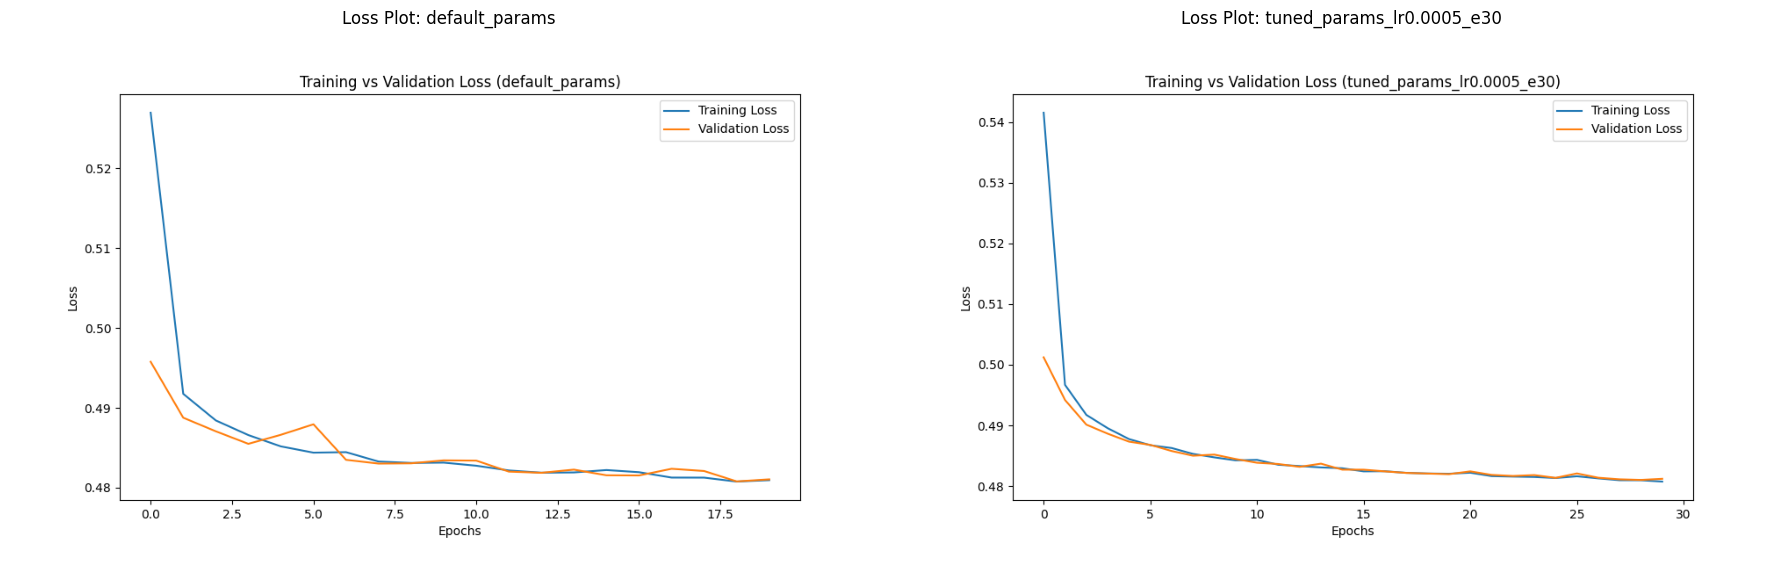

In [28]:
import matplotlib.image as mpimg

plt.figure(figsize=(18, 7))

# Load and display the loss plot for 'default_params'
plt.subplot(1, 2, 1)
img_default = mpimg.imread('loss_plot_default_params.png')
plt.imshow(img_default)
plt.title('Loss Plot: default_params')
plt.axis('off')

# Load and display the loss plot for 'tuned_params_lr0.0005_e30'
plt.subplot(1, 2, 2)
img_tuned = mpimg.imread('loss_plot_tuned_params_lr0.0005_e30.png')
plt.imshow(img_tuned)
plt.title('Loss Plot: tuned_params_lr0.0005_e30')
plt.axis('off')

plt.tight_layout()
plt.show()


### Compare Loss Plots of All Three Experiments

Let's visualize the loss plots from all three experiments to compare their training and validation performance.

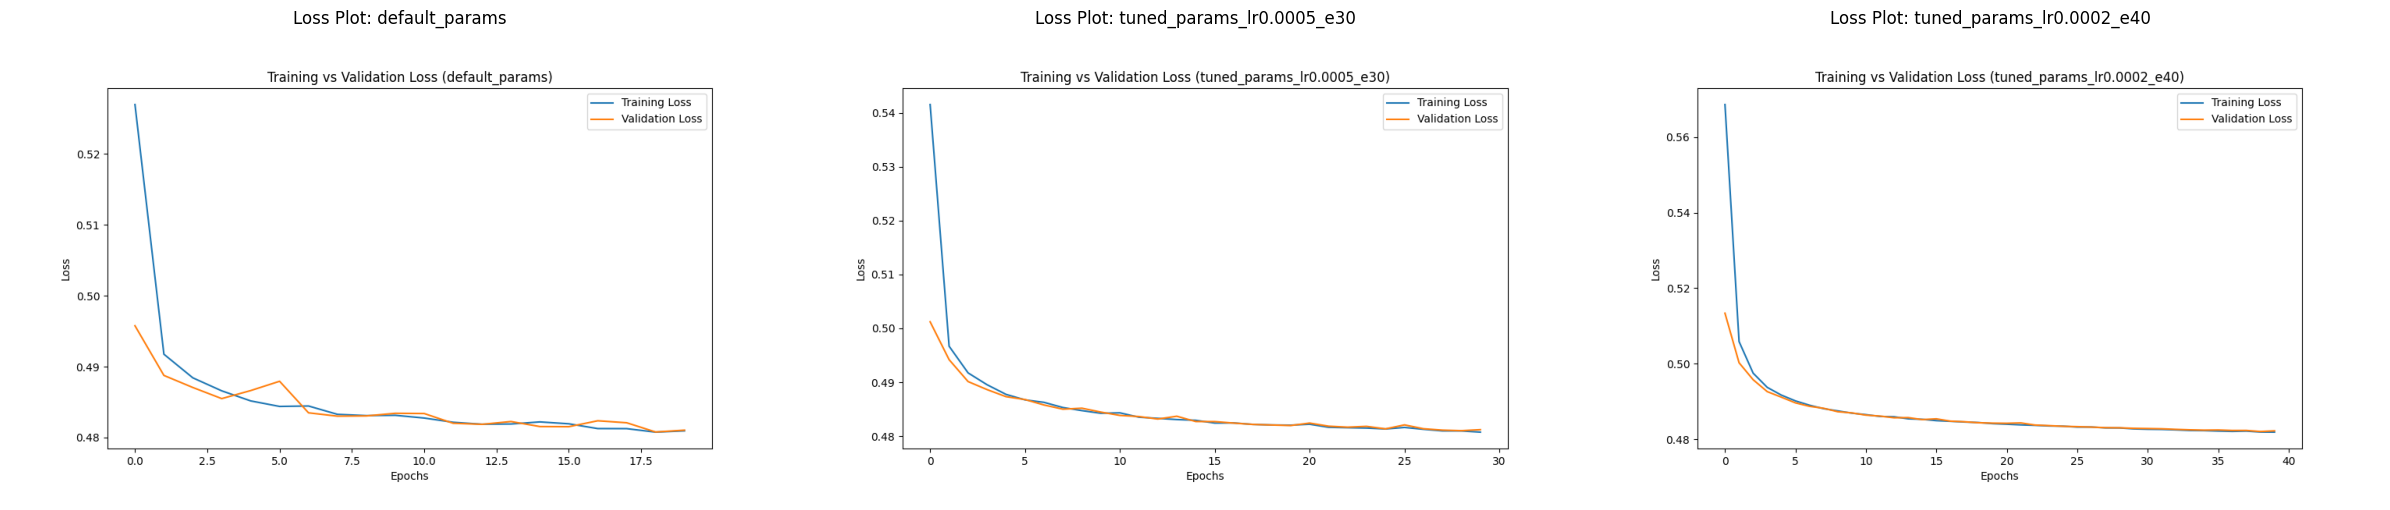

In [31]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 7))

# Load and display the loss plot for 'default_params'
plt.subplot(1, 3, 1)
img_default = mpimg.imread('loss_plot_default_params.png')
plt.imshow(img_default)
plt.title('Loss Plot: default_params')
plt.axis('off')

# Load and display the loss plot for 'tuned_params_lr0.0005_e30'
plt.subplot(1, 3, 2)
img_tuned_2 = mpimg.imread('loss_plot_tuned_params_lr0.0005_e30.png')
plt.imshow(img_tuned_2)
plt.title('Loss Plot: tuned_params_lr0.0005_e30')
plt.axis('off')

# Load and display the loss plot for 'tuned_params_lr0.0002_e40'
plt.subplot(1, 3, 3)
img_tuned_3 = mpimg.imread('loss_plot_tuned_params_lr0.0002_e40.png')
plt.imshow(img_tuned_3)
plt.title('Loss Plot: tuned_params_lr0.0002_e40')
plt.axis('off')

plt.tight_layout()
plt.show()

### Calculate Percentage Difference in Validation Loss for the Third Experiment

Let's calculate the percentage improvement in validation loss achieved by the third experiment compared to the first (default) experiment.

In [32]:
# Get the final validation loss from the first experiment (default_params)
default_val_loss = final_history.history['val_loss'][-1]

# Get the final validation loss from the third experiment (tuned_params_lr0.0002_e40)
third_val_loss = third_history.history['val_loss'][-1]

# Calculate the percentage difference
# Using the formula: ((old_value - new_value) / old_value) * 100
if default_val_loss != 0:
    percentage_difference_third = ((default_val_loss - third_val_loss) / default_val_loss) * 100
else:
    percentage_difference_third = 0 # Avoid division by zero

print(f"Final Validation Loss for 'default_params': {default_val_loss:.4f}")
print(f"Final Validation Loss for 'tuned_params_lr0.0002_e40': {third_val_loss:.4f}")
print(f"Percentage improvement in validation loss (third experiment vs default): {percentage_difference_third:.2f}%")

Final Validation Loss for 'default_params': 0.4810
Final Validation Loss for 'tuned_params_lr0.0002_e40': 0.4823
Percentage improvement in validation loss (third experiment vs default): -0.25%


### Calculate Percentage Difference in Validation Loss

Let's calculate the percentage improvement in validation loss achieved by the second, fine-tuned experiment compared to the default experiment.

In [29]:
# Get the final validation loss from the first experiment (default_params)
default_val_loss = final_history.history['val_loss'][-1]

# Get the final validation loss from the second experiment (tuned_params_lr0.0005_e30)
tuned_val_loss = second_history.history['val_loss'][-1]

# Calculate the percentage difference
# Using the formula: ((old_value - new_value) / old_value) * 100
if default_val_loss != 0:
    percentage_difference = ((default_val_loss - tuned_val_loss) / default_val_loss) * 100
else:
    percentage_difference = 0 # Avoid division by zero

print(f"Final Validation Loss for 'default_params': {default_val_loss:.4f}")
print(f"Final Validation Loss for 'tuned_params_lr0.0005_e30': {tuned_val_loss:.4f}")
print(f"Percentage improvement in validation loss: {percentage_difference:.2f}%")

# You can also consider the percentage change if the loss increased:
# percentage_change = ((tuned_val_loss - default_val_loss) / default_val_loss) * 100
# print(f"Percentage change in validation loss: {percentage_change:.2f}%")

Final Validation Loss for 'default_params': 0.4810
Final Validation Loss for 'tuned_params_lr0.0005_e30': 0.4812
Percentage improvement in validation loss: -0.03%


### Attempting Further Loss Reduction

To try and reduce the loss further, we will run another experiment with a lower learning rate and increased epochs. The goal is to allow the model to make finer adjustments over a longer training period.


--- Starting Experiment: tuned_params_lr0.0002_e40 ---
Learning Rate: 0.0002, Epochs: 40


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)


Training Model...
Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.5686 - val_loss: 0.5134
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.5059 - val_loss: 0.5003
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4975 - val_loss: 0.4958
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4938 - val_loss: 0.4926
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4917 - val_loss: 0.4912
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4902 - val_loss: 0.4897
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4890 - val_loss: 0.4887
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4881 - val_loss: 0.4882
Epoch 9/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4875 - val_loss: 0.4873
Epoch 10/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4869 - val_loss: 0.4870
Epoch 11/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4865 - val_loss: 0.4864
Epoch 12/40
125/125 ━━

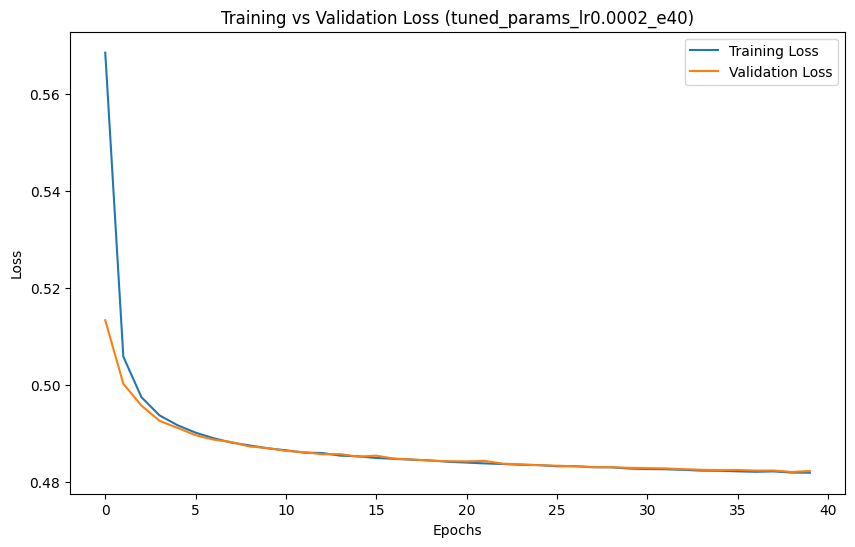

Loss plot saved as 'loss_plot_tuned_params_lr0.0002_e40.png'
Validation Loss for tuned_params_lr0.0002_e40: 0.48225945234298706


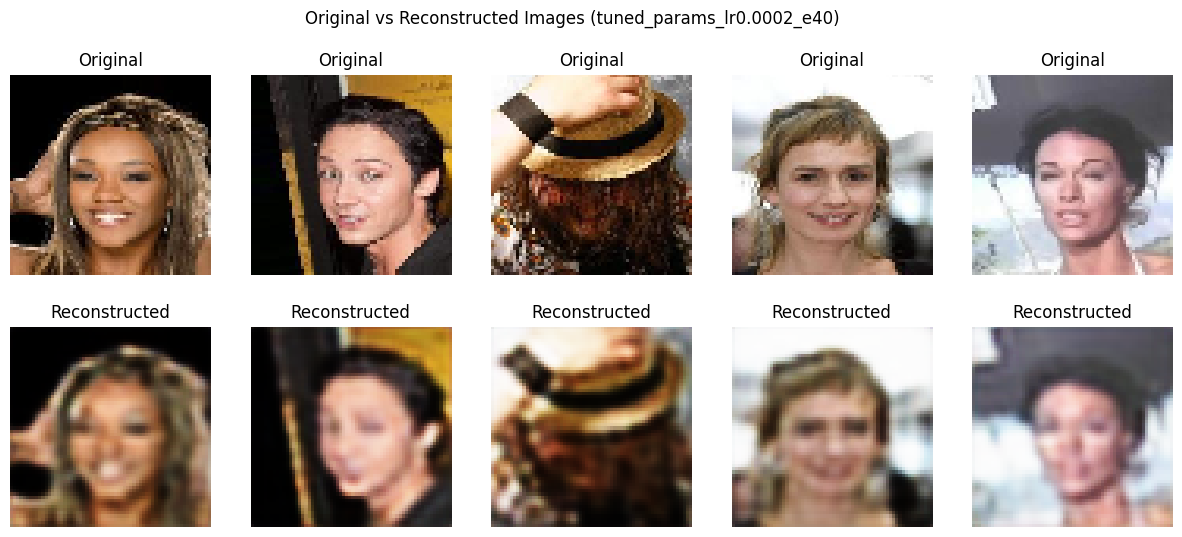

Reconstruction plot saved as 'reconstruction_plot_tuned_params_lr0.0002_e40.png'
Model saved as 'autoencoder_tuned_params_lr0.0002_e40.keras'
--- Experiment: tuned_params_lr0.0002_e40 Finished ---


In [30]:
# Define new hyperparameters for the third experiment
third_learning_rate = 0.0002
third_num_epochs = 40

# Run the function with the new parameters
third_autoencoder, third_history = train_and_evaluate_autoencoder(
    learning_rate=third_learning_rate,
    num_epochs=third_num_epochs,
    experiment_name='tuned_params_lr0.0002_e40'
)


## Saving the Model

It's important to save your trained model so you can reuse it later without needing to retrain. This also allows for deployment or further evaluation on new data. The model will be saved in the Keras H5 format.

In [24]:
# Save the autoencoder model in the native Keras format
autoencoder.save('autoencoder_celeba.keras')
print("Model saved successfully as 'autoencoder_celeba.keras'")

Model saved successfully as 'autoencoder_celeba.keras'


## Hyperparameter Tuning

To fine-tune the autoencoder, we can adjust its hyperparameters. Key hyperparameters include the learning rate of the optimizer, the number of training epochs, and the batch size. You can modify the values in the next cell to experiment with different configurations.

In [20]:
# Define Hyperparameters
LEARNING_RATE = 0.001  # Adjust this to control the step size of the optimizer
NUM_EPOCHS = 20      # Increase or decrease the number of training iterations
# BATCH_SIZE is already defined in an earlier cell (xyLooyOp7NTA) as 32